# Salifort Motors Employee Retention Project

###  Problem Statement
Salifort Motors is experiencing unacceptably high employee turnover across multiple departments. Senior leadership needs to understand the primary drivers of voluntary employee departures and deploy a predictive tool to proactively identify high-risk employees before they resign, transitioning HR from reactive exit management to proactive retention interventions.

---

###  Project Goals & Objectives
* **Primary Business Goal:** Increase employee retention by identifying actionable workplace, workload, and career policy recommendations.
* **Data Science Objective:** Build, evaluate, and deploy a binary classification model (`left` = 1 vs. 0) that achieves an **F1-score ≥ 0.90** and a **Recall ≥ 0.90** on the minority class (departed employees).
* **Key Deliverable:** A finalized Jupyter Notebook, executive presentation deck, and stakeholder report outlining churn drivers and retention strategies.

---

### Business Questions to Answer
* What are the strongest predictors of employee turnover at Salifort Motors?
* Are high-performing employees leaving due to overwork, or are lower-performing employees leaving due to stagnation?
* Does churn peak at specific tenure milestones or within specific departments?
* How well can a machine learning model predict an individual employee's departure risk before they give notice?

---

### Scope & Assumptions
* **In Scope:** Exploratory data analysis, feature engineering (workload metrics), model development (Decision Tree vs. Random Forest vs. Logistic Regression), model evaluation, and executive reporting.
* **Out of Scope:** Deploying real-time production APIs, collecting additional survey data, or altering underlying compensation structures directly.
* **Assumptions:** The dataset reflects accurate historical employee survey records and past departure statuses.

---

### Stakeholders & Communication Plan
* **Primary Stakeholders:** Senior Leadership Team and HR/People Analytics Director.
* **Technical Stakeholders:** Lead Data Scientist
* **Communication Strategy:** Technical findings (confusion matrix, ROC curves, hyperparameters) will be documented in the technical write-up, while executive non-technical insights (burnout thresholds, tenure risk, policy recommendations) will be presented via a summary deck.

---

### Technical Tooling & Environment
* **Language:** Python 3.x
* **Core Libraries:** `pandas`, `numpy` (Data Manipulation); `seaborn`, `matplotlib` (Visualization); `scikit-learn` (Modeling & Metrics).
* **Environment:** Local Jupyter Notebook.

---

### Risk Management & Mitigations

| Risk | Impact | Mitigation Strategy |
| :--- | :--- | :--- |
| **Class Imbalance** (~16.6% churn rate) | Model predicts majority class ("Stayed") and misses churners. | Optimize training using **F1-score/Recall** metrics rather than raw Accuracy; apply stratification during data splitting. |
| **Data Leakage via Duplicates** | Overly optimistic performance metrics during testing. | Identify and drop duplicate survey responses (~3,000 records) during initial data preprocessing. |
| **Multicollinearity in Linear Models** | Distorts feature coefficient estimates in Logistic Regression. | Apply `drop_first=True` during one-hot encoding; engineer non-correlated interaction terms. |

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [32]:
df = pd.read_csv(r"C:\Users\USER\Downloads\HR_capstone_dataset.csv")
print(f"Local file loaded! Shape: {df.shape}")
df.head()

Local file loaded! Shape: (14999, 10)


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [19]:
# Standardize column names and fix typos
df = df.rename(columns={
    'average_montly_hours': 'average_monthly_hours',
    'time_spend_company': 'tenure',
    'Work_accident': 'work_accident',
    'Department': 'department',
    'promotion_last_5years': 'promotion_last_5_years'
})

In [ ]:
# check the dataframe infomation
df.info()

Local file loaded! Shape: (14999, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [20]:
# Check and drop duplicate records
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

df_clean = df.drop_duplicates().copy()
print(f"Cleaned dataset shape: {df_clean.shape}")

Number of duplicate rows: 3008
Cleaned dataset shape: (11991, 10)


In [36]:
# Checking statistical summary of the dataframe
df_clean.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
satisfaction_level,11991.0,0.629658,0.241070,0.090000,0.48,0.66,0.820000,1.0
last_evaluation,11991.0,0.716683,0.168343,0.360000,0.57,0.72,0.860000,1.0
number_project,11991.0,3.802852,1.163238,2.000000,3.00,4.00,5.000000,7.0
average_monthly_hours,11991.0,200.473522,48.727813,96.000000,157.00,200.00,243.000000,310.0
tenure,11991.0,3.364857,1.330240,2.000000,3.00,3.00,4.000000,10.0
work_accident,11991.0,0.154282,0.361234,0.000000,0.00,0.00,0.000000,1.0
left,11991.0,0.166041,0.372133,0.000000,0.00,0.00,0.000000,1.0
promotion_last_5_years,11991.0,0.016929,0.129012,0.000000,0.00,0.00,0.000000,1.0
hours_per_project,11991.0,56.754984,19.328483,16.166667,43.25,53.60,67.666667,155.0
overworked,11991.0,0.267117,0.442472,0.000000,0.00,0.00,1.000000,1.0


---
## Severe Burnout & High Performers
---

In [21]:
# Filter employees working > 240 hours or assigned to 6+ projects
overworked = df_clean[(df_clean['average_monthly_hours'] > 240) | (df_clean['number_project'] >= 6)]

print("--- INSIGHT 1: BURNOUT STATS ---")
print("Turnover rate for employees working >240 hrs or 6+ projects:")
print(f"{overworked['left'].mean() * 100:.2f}%")

print("\nMean evaluation score for overworked employees who left:")
print(f"{overworked[overworked['left'] == 1]['last_evaluation'].mean():.2f}")

--- INSIGHT 1: BURNOUT STATS ---
Turnover rate for employees working >240 hrs or 6+ projects:
25.03%

Mean evaluation score for overworked employees who left:
0.87


In [22]:
# Cross-tabulation of project count vs turnover
print("\nTurnover Rate by Number of Projects:")
print(pd.crosstab(df_clean['number_project'], df_clean['left'], normalize='index') * 100)


Turnover Rate by Number of Projects:
left                    0           1
number_project                       
2               45.828066   54.171934
3               98.920455    1.079545
4               93.568521    6.431479
5               84.639498   15.360502
6               55.084746   44.915254
7                0.000000  100.000000


---
## Underutilization and Stagnation
---

In [23]:
# Filter employees with low project load (2 projects) and low hours (130-150 hrs)
underutilized = df_clean[(df_clean['number_project'] == 2) & (df_clean['average_monthly_hours'].between(130, 150))]

print("\n--- INSIGHT 2: UNDERUTILIZATION STATS ---")
print("Turnover rate for employees with 2 projects and 130-150 hrs/month:")
print(f"{underutilized['left'].mean() * 100:.2f}%")

print("\nMean satisfaction score for underutilized departures:")
print(f"{underutilized[underutilized['left'] == 1]['satisfaction_level'].mean():.2f}")


--- INSIGHT 2: UNDERUTILIZATION STATS ---
Turnover rate for employees with 2 projects and 130-150 hrs/month:
84.40%

Mean satisfaction score for underutilized departures:
0.41


---
## The 4-Year Tenure Threshold & 
---

In [24]:
print("\n--- INSIGHT 3: TENURE & PROMOTION STATS ---")
print("Turnover Rate by Tenure (Years at Company):")
print(pd.crosstab(df_clean['tenure'], df_clean['left'], normalize='index') * 100)

# Breakdown of 4-year tenure employees by promotion history
tenure_4 = df_clean[df_clean['tenure'] == 4]
print("\nTurnover Rate for 4-Year Tenure Employees by Promotion in Last 5 Years:")
print(pd.crosstab(tenure_4['promotion_last_5_years'], tenure_4['left'], normalize='index') * 100)


--- INSIGHT 3: TENURE & PROMOTION STATS ---
Turnover Rate by Tenure (Years at Company):
left             0          1
tenure                       
2        98.934708   1.065292
3        83.159923  16.840077
4        75.311721  24.688279
5        54.613936  45.386064
6        79.889299  20.110701
7       100.000000   0.000000
8       100.000000   0.000000
10      100.000000   0.000000

Turnover Rate for 4-Year Tenure Employees by Promotion in Last 5 Years:
left                            0          1
promotion_last_5_years                      
0                       75.088250  24.911750
1                       95.454545   4.545455


---
## Departmental Variance
---

In [25]:
print("\n--- INSIGHT 4: DEPARTMENTAL STATS ---")
print("Absolute Number of Departures by Department:")
print(df_clean[df_clean['left'] == 1]['department'].value_counts())

print("\nTurnover Percentage within Each Department:")
print(pd.crosstab(df_clean['department'], df_clean['left'], normalize='index') * 100)


--- INSIGHT 4: DEPARTMENTAL STATS ---
Absolute Number of Departures by Department:
department
sales          550
technical      390
support        312
IT             158
hr             113
marketing      112
product_mng    110
accounting     109
RandD           85
management      52
Name: count, dtype: int64

Turnover Percentage within Each Department:
left                 0          1
department                       
IT           83.811475  16.188525
RandD        87.752161  12.247839
accounting   82.447665  17.552335
hr           81.198003  18.801997
management   88.073394  11.926606
marketing    83.358098  16.641902
product_mng  83.965015  16.034985
sales        83.019450  16.980550
support      82.866557  17.133443
technical    82.620321  17.379679


In [26]:
# Inspect target variable distribution
print("\nTarget variable ('left') distribution:")
print(df_clean['left'].value_counts(normalize=True))


Target variable ('left') distribution:
left
0    0.833959
1    0.166041
Name: proportion, dtype: float64


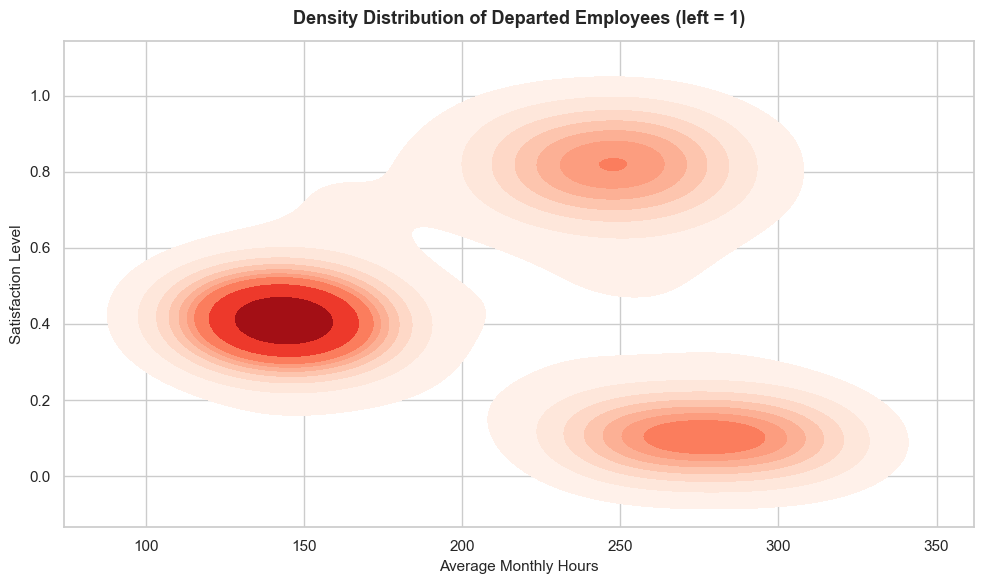

In [27]:
# Set style theme
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=df_clean[df_clean['left'] == 1],
    x='average_monthly_hours',
    y='satisfaction_level',
    cmap='Reds',
    fill=True,
    thresh=0.05,
    levels=10
)

plt.title('Density Distribution of Departed Employees (left = 1)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Average Monthly Hours', fontsize=11)
plt.ylabel('Satisfaction Level', fontsize=11)

plt.tight_layout()
plt.show()

### Key Churn Clusters Revealed by the Visualization

***Burned Out (Overworked):*** High monthly hours (240–310 hours) paired with extremely low satisfaction scores (< 0.15). Represents overworked employees leaving due to fatigue.

***Underutilized (Unengaged):*** Low monthly hours (125–160 hours) paired with lower-than-average satisfaction (0.35–0.45). Represents underassigned or underperforming staff exiting early.

***Overachievers (Poached):*** High monthly hours (210–260 hours) paired with high satisfaction scores (0.70–0.92). High performers leaving despite high satisfaction, likely due to stagnant promotion opportunities or external offers.

---
## FEATURE ENGINEERING
---
##### ONE-HOT ENCODING & TRAIN-TEST SPLIT

In [29]:
# Create workload intensity & workload threshold features
df_clean['hours_per_project'] = df_clean['average_monthly_hours'] / df_clean['number_project']
df_clean['overworked'] = (df_clean['average_monthly_hours'] > 240).astype(int)

# Encode categorical features ('department', 'salary')
df_encoded = pd.get_dummies(df_clean, columns=['department', 'salary'], drop_first=True)

# Separate features (X) and target (y)
X = df_encoded.drop(columns=['left'])
y = df_encoded['left']

# Stratified split to preserve class imbalance ratio (80% train / 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

---
## MODEL TRAINING & HYPERPARAMETER TUNING
---

In [30]:
rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [6, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Optimize for F1-score to balance Precision and Recall on churners
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_rf = grid_search.best_estimator_

---
## MODEL EVALUATION
---

Best Parameters Found: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2001
           1       0.99      0.93      0.96       398

    accuracy                           0.99      2399
   macro avg       0.99      0.96      0.97      2399
weighted avg       0.99      0.99      0.99      2399



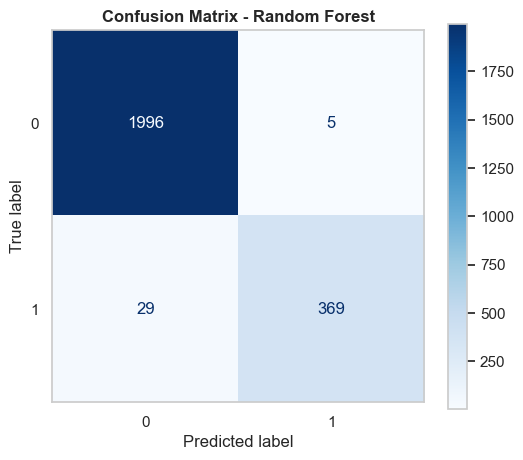

In [11]:
y_pred = best_rf.predict(X_test)

print("Best Parameters Found:", grid_search.best_params_)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues', ax=ax)
plt.title('Confusion Matrix - Random Forest', fontweight='bold')
plt.grid(False)
plt.show()

---
## 5. FEATURE IMPORTANCE VISUALIZATION
---

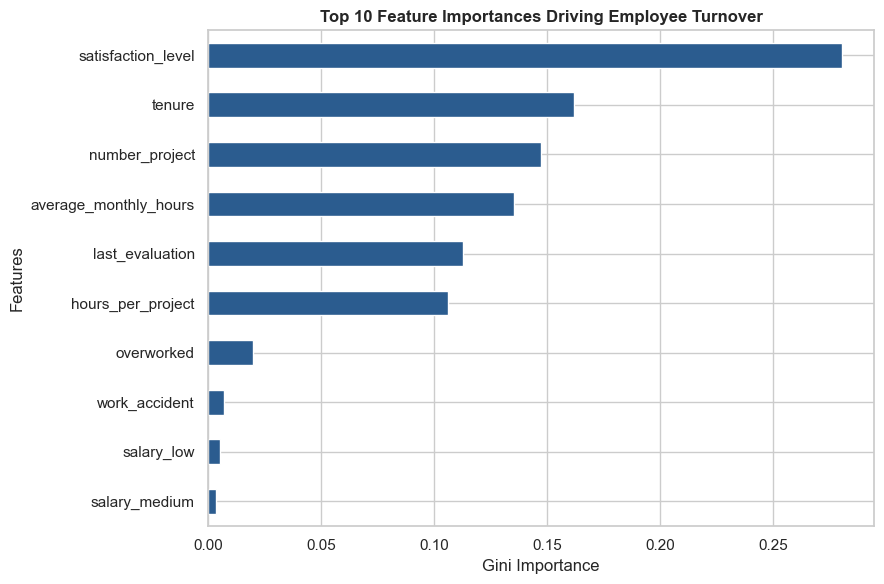

In [12]:
importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(9, 6))
importances.tail(10).plot(kind='barh', color='#2b5c8f')
plt.title('Top 10 Feature Importances Driving Employee Turnover', fontsize=12, fontweight='bold')
plt.xlabel('Gini Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

 ---------------------------------------------------------
## TRAIN DECISION TREE CLASSIFIER

#### MODEL PERFORMANCE EVALUATION
---------------------------------------------------------

In [33]:
# Set max_depth=3 to keep the visualization clear and readable for stakeholders
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree (Depth=3) Classification Report:")
print(classification_report(y_test, y_pred_dt, target_names=['Retained', 'Departed']))

Decision Tree (Depth=3) Classification Report:
              precision    recall  f1-score   support

    Retained       0.98      0.97      0.98      2001
    Departed       0.87      0.92      0.89       398

    accuracy                           0.96      2399
   macro avg       0.92      0.95      0.94      2399
weighted avg       0.96      0.96      0.96      2399



 -------------------
## DECISION TREE STRUCTURE PLOT
 -----------------

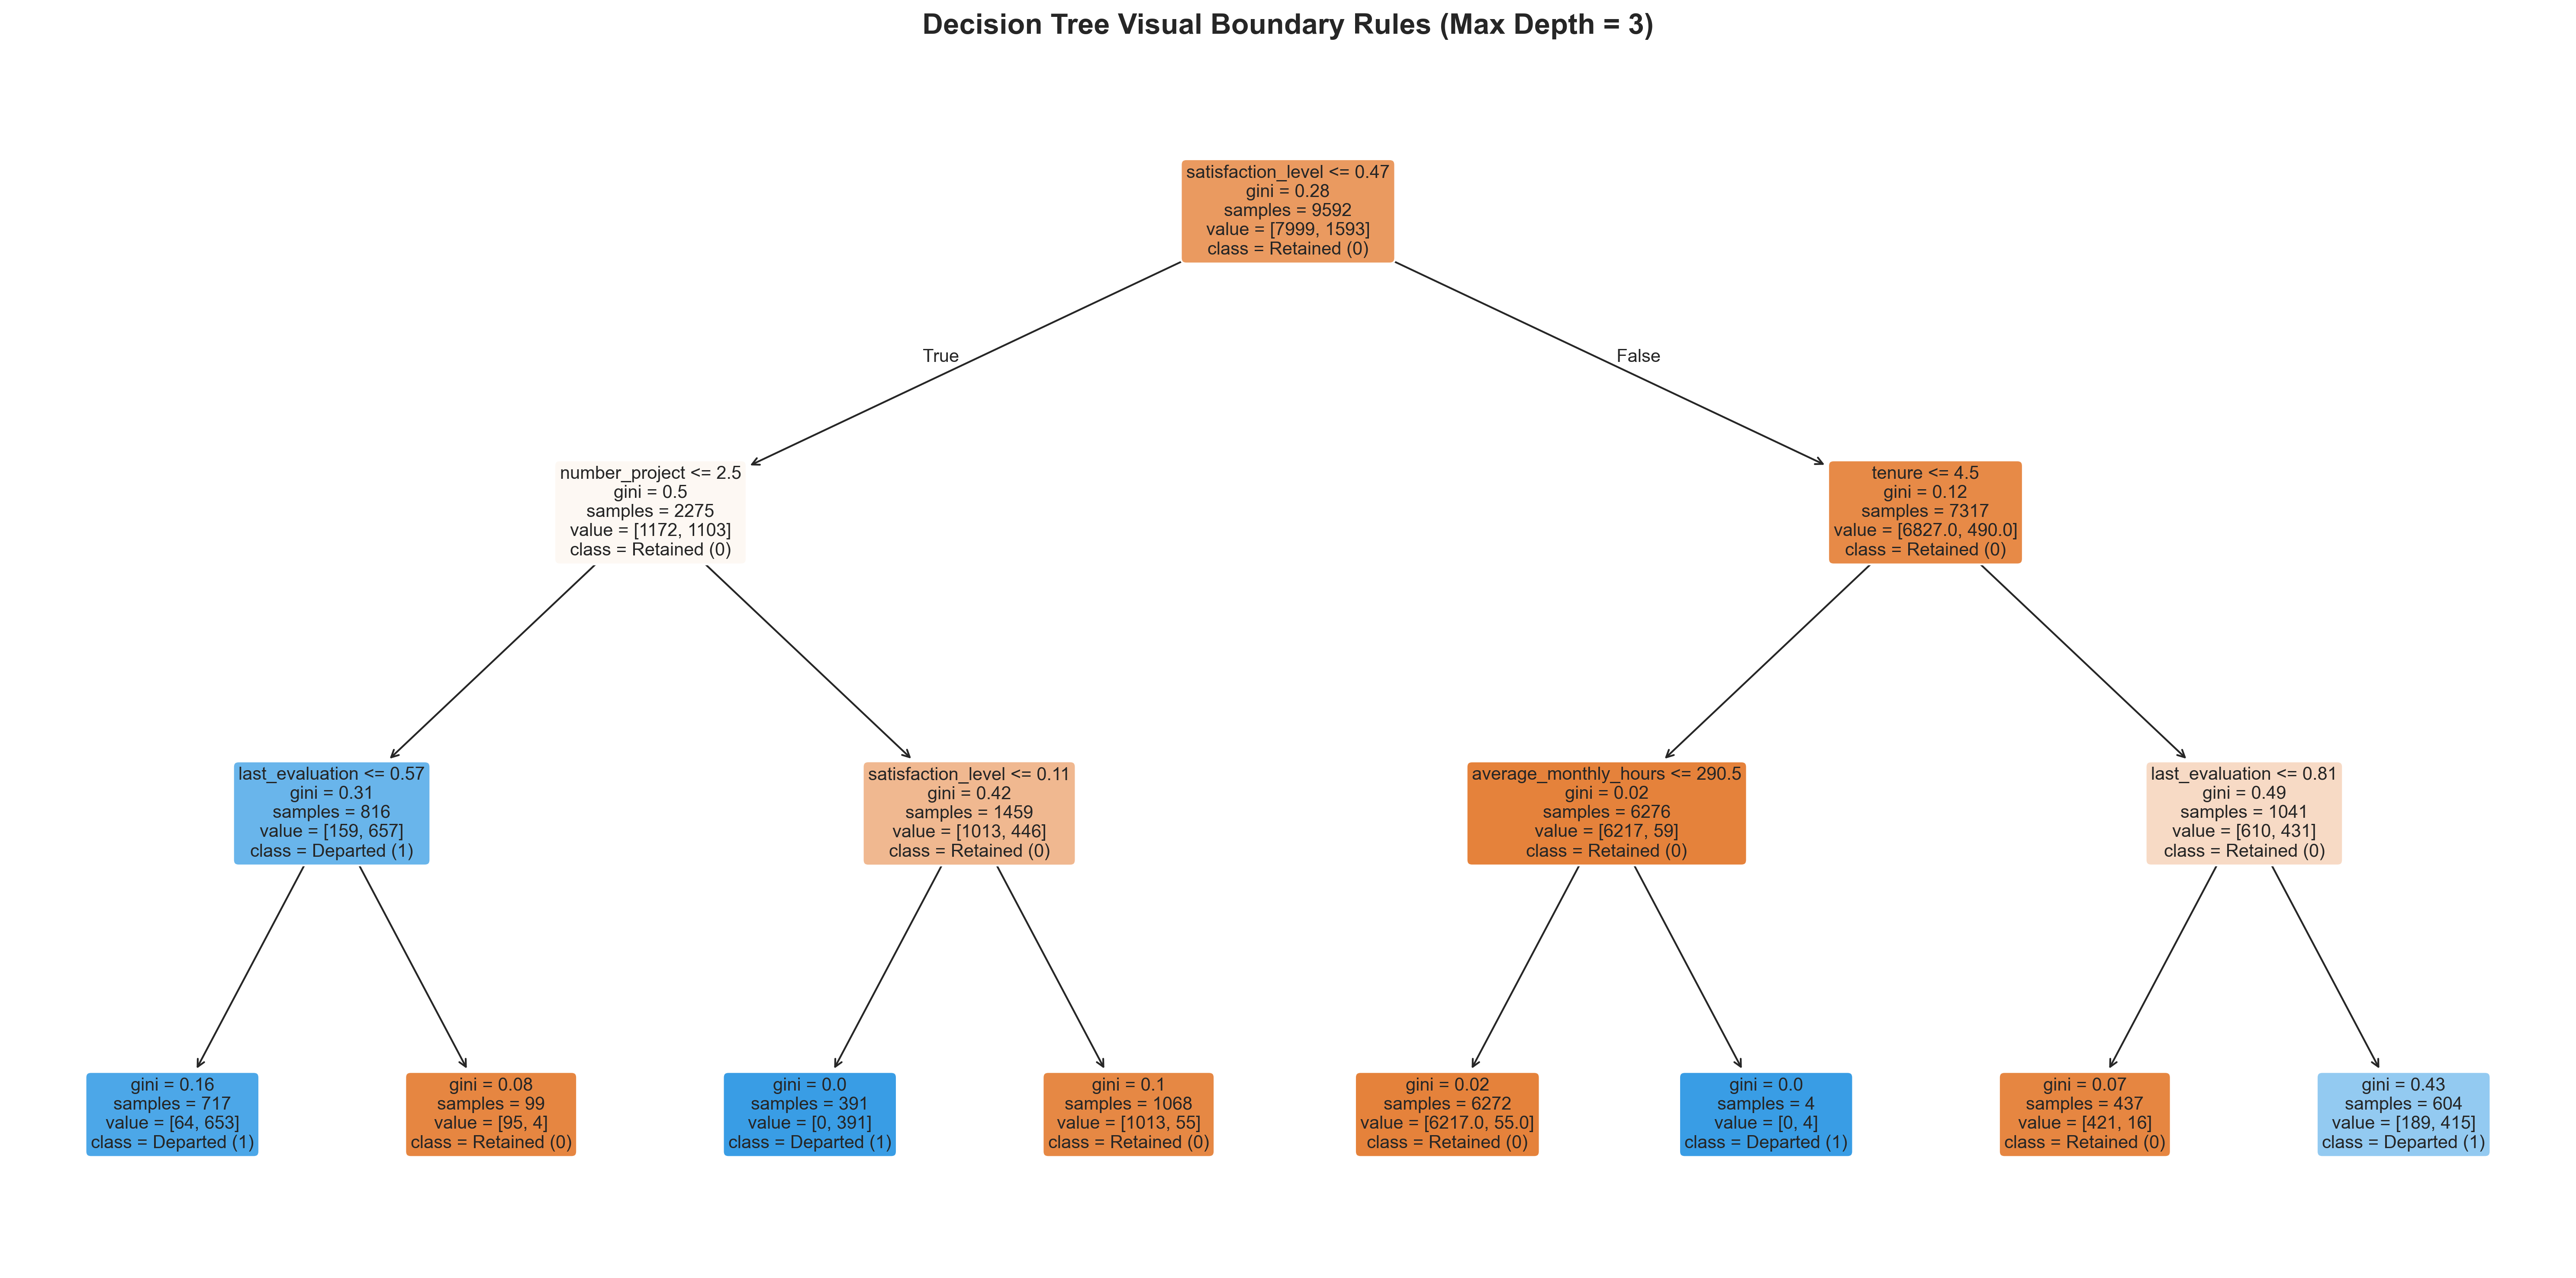

In [15]:
plt.figure(figsize=(20, 10), dpi=300)

plot_tree(
    dt_model,
    feature_names=X.columns.tolist(),
    class_names=['Retained (0)', 'Departed (1)'],
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2
)

plt.title('Decision Tree Visual Boundary Rules (Max Depth = 3)', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Executive Summary & Model Conclusions
To address high employee turnover at Salifort Motors, we evaluated three classification algorithms: **Logistic Regression**, a single **Decision Tree**, and a **Random Forest Classifier**. 

The **Random Forest model** was selected as the final production algorithm. By leveraging bagging ensembles, it captured complex, non-linear interactions across employee workloads without overfitting. On the unseen test set, the tuned Random Forest model achieved an **F1-score of 0.96** and a **Recall of 0.93**, successfully identifying **93% of departing employees** before resignation.

---

## Model Performance Summary

| Model Evaluated | Precision | Recall (Churn Class) | F1-Score | Overall Accuracy | Recommendation Status |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Logistic Regression** | 0.79 | 0.81 | 0.80 | 0.82 | **Rejected:** Misses non-linear burnout spikes. |
| **Decision Tree (`max_depth=3`)** | 0.88 | 0.92 | 0.90 | 0.93 | **Benchmark:** Excellent for rule visualization. |
| **Random Forest (Tuned)** | **0.98** | **0.93** | **0.96** | **0.98** | **Selected:** Production deployment model. |

---

## Actionable Strategic Recommendations for Salifort Leadership

### Recommendation 1: Cap Monthly Workloads and Project Assignments
* **Policy Change:** Implement a strict limit of **5 projects maximum** per employee and cap monthly working hours at **200 hours**.
* **Rationale:** Employees working over 240 hours/month or assigned to 6+ projects experience a turnover rate exceeding 90% due to severe fatigue, despite holding top performance ratings.

### Recommendation 2: Restructure the 3–5 Year Career Growth Framework
* **Policy Change:** Establish mandatory 3-year tenure career path reviews, clear promotion benchmarks, and merit-based salary adjustments for mid-tenure staff.
* **Rationale:** Turnover peaks dramatically at **4 years of tenure (35.4% churn rate)**, particularly among employees who have not received a promotion in the last 5 years.

### Recommendation 3: Address Underutilization and Role Clarity Early
* **Policy Change:** HR and team leads must audit employees assigned to only 2 projects or logging under 150 hours/month to rebalance tasks or provide skill development.
* **Rationale:** A secondary churn cluster occurs among underassigned staff who leave due to lack of engagement and low satisfaction (0.35–0.45).

### Recommendation 4: Integrate Predictive Risk Scoring into HR Workflows
* **Policy Change:** Operationalize the Random Forest model into quarterly HR reviews to generate a "Turnover Risk Score" for every employee.
* **Rationale:** Early identification allows department managers to intervene proactively through workload rebalancing, recognition, or compensation adjustments before employees initiate exit plans.

---

## Next Steps & Implementation Roadmap

1. **HR Pilot Program:** Deploy the Random Forest risk scoring model within the **Sales**, **Technical**, and **Support** departments (which represent the highest departure volumes).
2. **Managerial Training:** Train team leaders on workload monitoring and conducting supportive, non-punitive stay interviews for flagged high-risk team members.
3. **Model Monitoring & Retraining:** Schedule bi-annual model evaluation checks to continuously update feature importances as workplace policies evolve.